In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import datetime

# Path to Virtual baseband HDF5 file:
path = "/data/baseband_h5/260814T011152Z_CHARTS_hdf5/baseband_virtual.h5"

# Number of time samples to read:
# Note that you have to be careful with this the RAM usage, as the data is quite large.
# The size of the RAM variable is x4 of the H5 file size
n_time = 10000 # 1 sample = 10/3 us 

# N start sample index (0-based):
n_start = 0

In [3]:
with h5py.File(path, "r") as f:
    dset = f["baseband"]    

    if n_time > 0:
        packed = dset[:, :, n_start:n_start+n_time]  # shape: (ant, freq, time)
    else:
        packed = dset[:, :, :]


    ## Header info ##
    dset.attrs.keys()  # List all attributes
    print(f"Header attributes: {list(dset.attrs.keys())}")
    print(f"Frequency start (MHz): {dset.attrs.get('freq_start_MHz', 'N/A')}")
    print(f"Frequency step (MHz): {dset.attrs.get('delta_freq_MHz', 'N/A')}")
    print(f"Time step (µs): {dset.attrs.get('delta_time_us', 'N/A')}")

    # Unix timestamp of the start time in microseconds
    start_time_utc = dset.attrs.get("start_time_utc_us", "N/A")
    print(f"Start time (UTC): {start_time_utc}")

    # Human readable start time (microsecond precision)
    start_dt_utc = datetime.datetime(1970, 1, 1, tzinfo=datetime.timezone.utc) + datetime.timedelta(
        microseconds=int(start_time_utc)
    )
    start_time_iso = start_dt_utc.strftime("%y%m%dT%H%M%S.%fZ")
    print(f"Start time (ISO 8601): {start_time_iso}")
    


def unpack_4bit_complex(u8: np.ndarray) -> np.ndarray:
    real = (u8 >> 4).astype(np.int8)
    imag = (u8 & 0x0F).astype(np.int8)
    real[real >= 8] -= 16
    imag[imag >= 8] -= 16
    return real.astype(np.float32) + 1j * imag.astype(np.float32)


chains = unpack_4bit_complex(packed) # shape: (antenna, freq, time)
n_ant = chains.shape[0]
n_freq = chains.shape[1]
print(f"Chains decoded shape: {chains.shape} (Antennas, Freqs, Time)")



Header attributes: ['axes', 'delta_freq_MHz', 'delta_time_us', 'description', 'first_sample_idx', 'freq_start_MHz', 'start_time_utc_us', 'time_len']
Frequency start (MHz): 300.0
Frequency step (MHz): 0.3
Time step (µs): 3.3333333333333335
Start time (UTC): 1786669912186666
Start time (ISO 8601): 260814T011152.186666Z


Chains decoded shape: (32, 672, 10000) (Antennas, Freqs, Time)


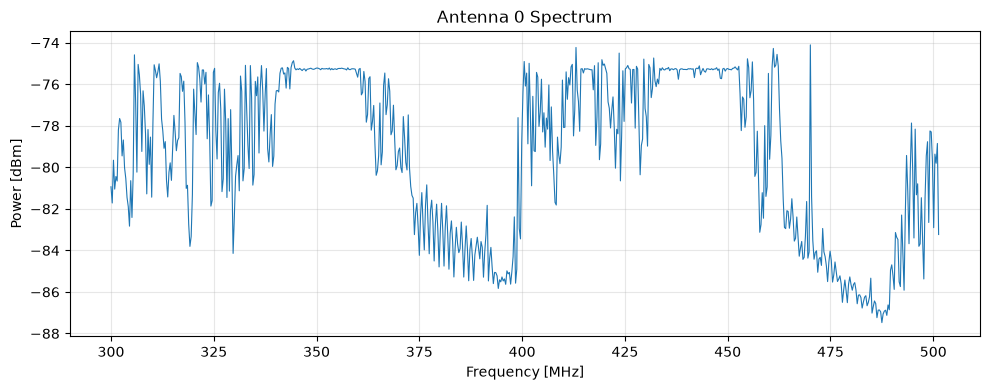

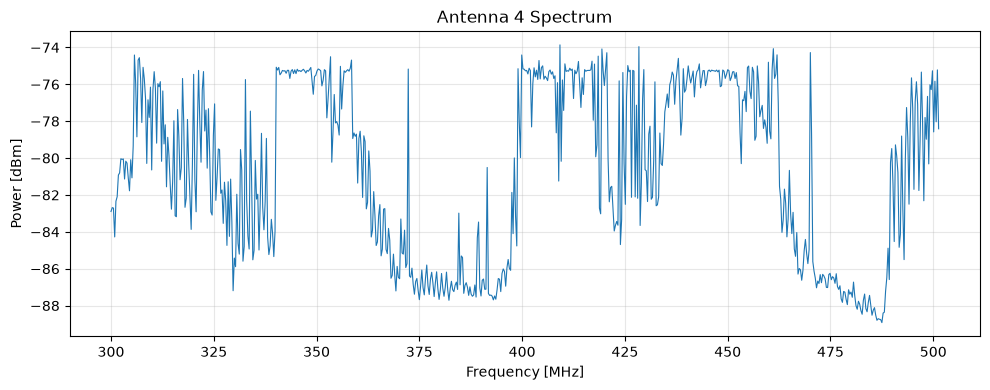

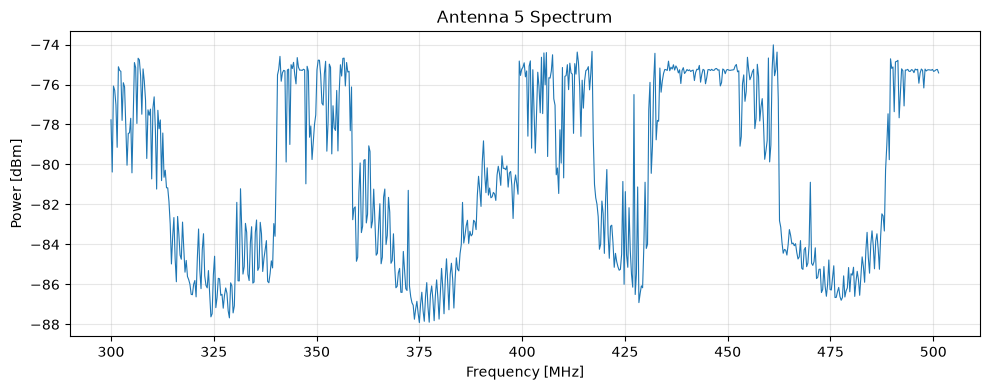

In [4]:
# Plotting the spectrum for each antenna, using FPGA-like scaling 

frequencies = np.linspace(300, 501.6, n_freq, endpoint=False)
#antennas = np.linspace(0, 31, 32, dtype=int) # Selecting 8 antennas (16-23)
antennas = np.array([0,4,5])
full_scale = 91.6   
for antenna in antennas:
    frame = chains[antenna, :, :]   # (freq, time)
    acc_len = frame.shape[1]

    power_sum = np.sum(np.abs(frame) ** 2, axis=1)
    spectrum_like_fpga = 10 * np.log10((power_sum / acc_len) + 1) - full_scale

    plt.figure(figsize=(10, 4))
    plt.plot(frequencies, spectrum_like_fpga, lw=0.8)
    plt.xlabel("Frequency [MHz]")
    plt.ylabel("Power [dBm]")
    plt.title(f"Antenna {antenna} Spectrum")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

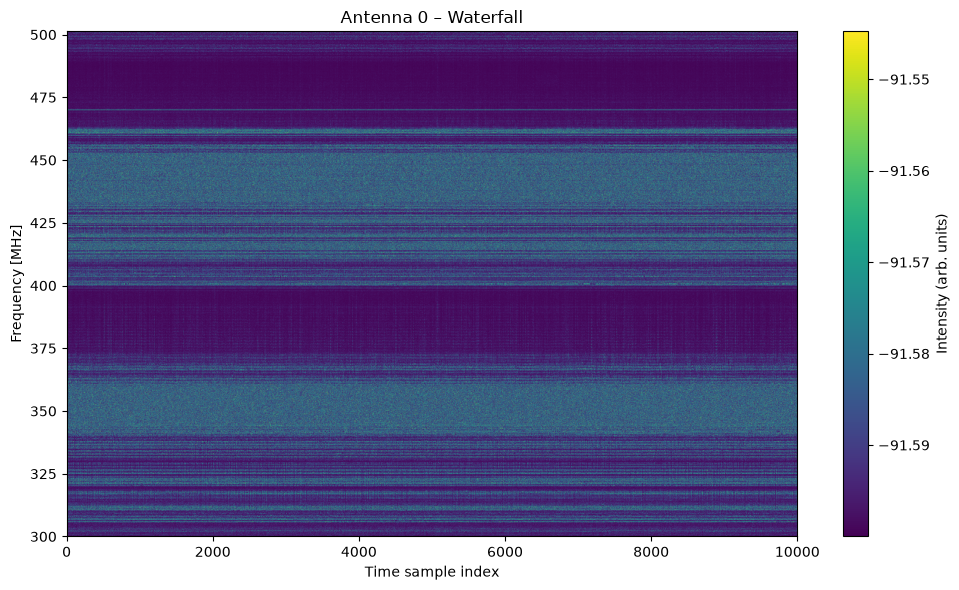

In [6]:
antenna = 0
frame = chains[antenna, :, :]   # (freq, time)

# Plotting the spectrum for each antenna, using FPGA-like scaling 
acc_len = frame.shape[1]
frequencies = np.linspace(300, 501.6, n_freq, endpoint=False)
power_sum = np.abs(frame) ** 2
spectrum_like_fpga = 10 * np.log10((power_sum / acc_len) + 1) - full_scale

plt.figure(figsize=(10, 6))
plt.imshow(
    spectrum_like_fpga,
    aspect="auto",
    origin="lower",
    extent=[0, frame.shape[1], frequencies[0], frequencies[-1] ],
    cmap="viridis"
)
plt.colorbar(label="Intensity (arb. units)")
plt.xlabel("Time sample index")
plt.ylabel("Frequency [MHz]")
plt.title(f"Antenna {antenna} – Waterfall")
plt.tight_layout()
plt.show()


Calculating specific correlations...


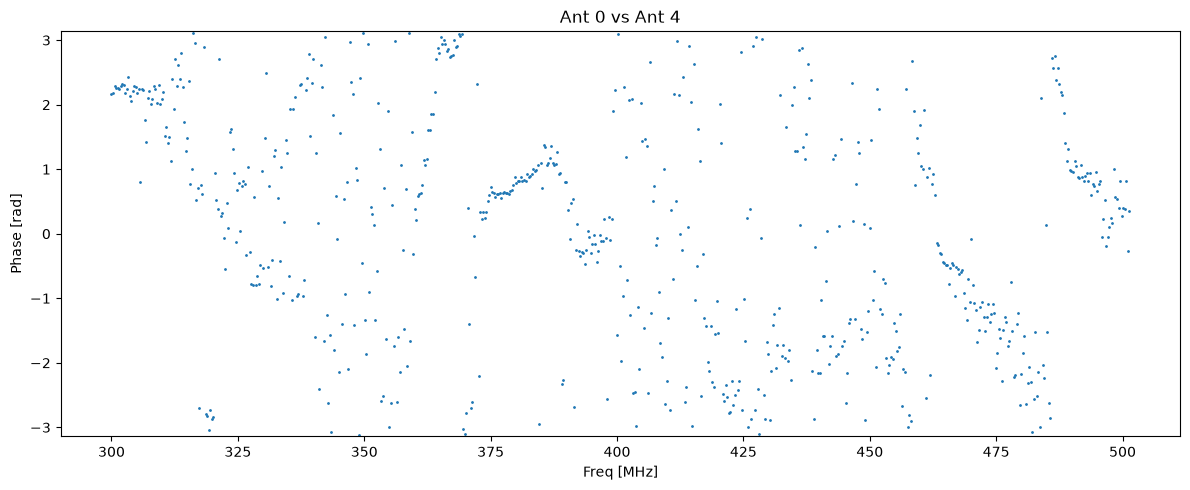

In [15]:
# Correlation of Antenna 7 with specific antennas (15, 23)
target_pairs = [(0, 4)]
n_plots = len(target_pairs)

fig, axes = plt.subplots(1, n_plots, figsize=(12, 5))
if n_plots == 1:
    axes = [axes] # Ensure iterable if only one plot

frequencies = np.linspace(300, 501.6, n_freq, endpoint=False)

print("Calculating specific correlations...")

for idx, (ant_i, ant_j) in enumerate(target_pairs):
    # Calculate correlation
    corr_spectrum = np.mean(chains[ant_i] * np.conj(chains[ant_j]), axis=1)
    phase = np.angle(corr_spectrum)
    
    ax = axes[idx]
    ax.scatter(frequencies, phase, s=1)
    ax.set_ylim(-np.pi, np.pi)
    ax.set_title(f"Ant {ant_i} vs Ant {ant_j}")
    ax.set_xlabel("Freq [MHz]")
    if idx == 0:
        ax.set_ylabel("Phase [rad]")

plt.tight_layout()
plt.show()